<a href="https://colab.research.google.com/github/pankhudi-priyal/ai-vs-human-text-detection/blob/main/2_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/AI_Human.csv')
print("Dataset loaded! Shape:", df.shape)

Dataset loaded! Shape: (487235, 2)


Training samples: 40000
Testing samples:  10000

Tokenizing text...
Tokenizing complete!

Building LSTM model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training LSTM...
Epoch 1/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 87s 148ms/step - accuracy: 0.9363 - loss: 0.1741 - val_accuracy: 0.9785 - val_loss: 0.0688
Epoch 2/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 142s 148ms/step - accuracy: 0.9835 - loss: 0.0611 - val_accuracy: 0.9818 - val_loss: 0.0535
Epoch 3/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 85s 151ms/step - accuracy: 0.9891 - loss: 0.0401 - val_accuracy: 0.9805 - val_loss: 0.0658
Epoch 4/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 86s 154ms/step - accuracy: 0.9834 - loss: 0.0580 - val_accuracy: 0.9833 - val_loss: 0.0682
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step

Classification Report:
              precision    recall  f1-score   support

       Human       0.98      0.99      0.99      6327
          AI       0.98      0.97      0.97      3673

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



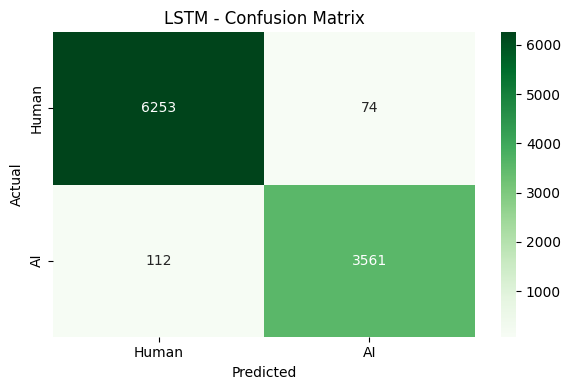

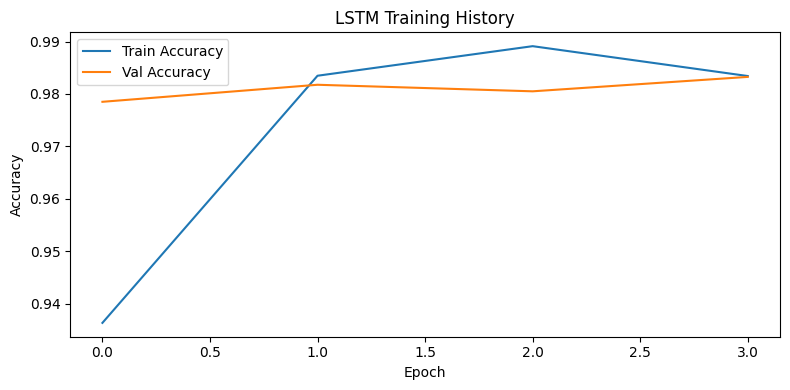

Done!


In [5]:
# ============================================
# LSTM MODEL
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

#Prepare Data
df_sample = df.sample(n=50000, random_state=42)

X = df_sample['text'].astype(str).values
y = df_sample['generated'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

#Tokenize Text
print("\nTokenizing text...")
MAX_WORDS = 10000   # vocabulary size
MAX_LEN   = 200     # max words per sample

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, truncating='post')
print("Tokenizing complete!")

#Build LSTM Model
print("\nBuilding LSTM model...")
model = Sequential([
    Embedding(MAX_WORDS, 64, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

#Train
print("\nTraining LSTM...")
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

#Evaluate
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Human', 'AI']))

#Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Human', 'AI'],
            yticklabels=['Human', 'AI'])
plt.title('LSTM - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png')
plt.show()

#Plot Training History
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_training_history.png')
plt.show()
print("Done!")